In [11]:
from langgraph.graph import StateGraph, START, END
from typing import List, Dict, Optional, Annotated, Literal
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import operator

load_dotenv()

True

In [12]:
generator_model = ChatGroq(model="openai/gpt-oss-20b")
evaluator_model = ChatGroq(model="openai/gpt-oss-20b")
optimizer_model = ChatGroq(model="openai/gpt-oss-20b")

In [13]:
class PostEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(
        description = "Final Evaaluation Result" 
    )

    feedback: str = Field(
        description = "feedback for the facebook post."
    )

In [14]:
structured_evaluator_llm = evaluator_model.with_structured_output(PostEvaluation)

In [15]:
class PostState(BaseModel):
    topic: str
    post: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int

    post_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [16]:
def generate_post(state: PostState):
    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Facebook influencer."),
        HumanMessage(content=f"""
            Write a short, original, and hilarious Facebook post on the topic: "{state.topic}".
            Rules:
            - Do NOT use question-answer format.
            - Max 500 characters.
            - Use observational humor, irony, sarcasm, or cultural references.
            - Think in meme logic, punchlines, or relatable takes.
            - Use simple, day to day english
        """)
    ]

    response = generator_model.invoke(messages).content

    return{
        'post': response,
        'post_history': [response]
    }

In [17]:
def evaluate_post(state: PostState):
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Facebook critic. You evaluate posts based on humor, originality, virality, and post format."),
    HumanMessage(content=f"""
            Evaluate the following Facebook post:

            Post: "{state.post}"

            Use the criteria below to evaluate the post:

            1. Originality – Is this fresh, or have you seen it a hundred times before?  
            2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
            3. Punchiness – Is it short, sharp, and scroll-stopping?  
            4. Virality Potential – Would people share, react, or comment on it?  
            5. Format – Is it a well-formed Facebook post (not a setup-punchline joke, not a Q&A joke, and under 500 characters)?

            Auto-reject if:
            - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
            - It exceeds 500 characters
            - It reads like a traditional setup-punchline joke
            - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

            ### Respond ONLY in structured format:
            - evaluation: "approved" or "needs_improvement"  
            - feedback: One paragraph explaining the strengths and weaknesses 
            """)
        ]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [18]:
def optimize_post(state: PostState):

    messages = [
        SystemMessage(content="You punch up Facebook posts for virality and humor based on given feedback."),
        HumanMessage(content=f"""
            Improve the Facebook post based on this feedback:
            "{state['feedback']}"

            Topic: "{state['topic']}"
            Original Post:
            {state['post']}

            Re-write it as a short, viral-worthy Facebook post. Avoid Q&A style and stay under 500 characters.
        """)
        ]

    response = optimizer_model.invoke(messages).content
    iteration = state['iteration'] + 1

    return {
        'post': response, 
        'iteration': iteration, 
        'post_history': [response]
        }

In [ ]:
def route_evaluation(state: PostState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

In [20]:
graph = StateGraph(PostState)

# nodes
graph.add_node('generate', generate_post)
graph.add_node('evaluate', evaluate_post)
graph.add_node('optimize', optimize_post)


# edges
graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')
graph.add_conditional_edges('evaluate',route_evaluation,{'approved': END, 'needs_improvement': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()

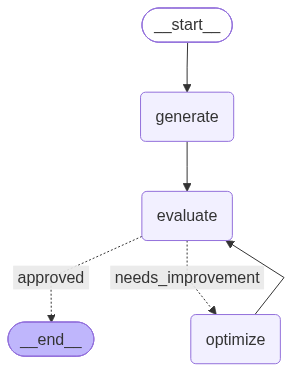

In [21]:
workflow